In [ ]:
!pip install pyspark


In [ ]:
from pyspark.sql import SparkSession
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
spark = SparkSession.builder.appName("BigDataAnalysis").getOrCreate()

In [ ]:
spark

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving sales_data.csv to sales_data.csv


In [ ]:
df = spark.read.csv("sales_data.csv", header=True, inferSchema=True)

df.show()

+----------+---------------+------+-----+--------+------+
|   Product|       Category|Region|Sales|Quantity|Profit|
+----------+---------------+------+-----+--------+------+
|    Laptop|     Technology| South| 1200|       2|   200|
|     Phone|     Technology|  West|  800|       3|   150|
|    Tablet|     Technology|  East|  650|       4|   120|
|   Monitor|     Technology| North|  400|       2|    80|
|  Keyboard|     Technology| South|  120|       6|    40|
|     Mouse|     Technology|  West|   60|      10|    20|
|   Printer|     Technology|  East|  350|       3|    90|
|     Chair|      Furniture| South|  180|       5|    60|
|      Desk|      Furniture|  West|  320|       2|    90|
|  Bookcase|      Furniture|  East|  210|       3|    70|
|     Table|      Furniture| North|  450|       2|   110|
|      Sofa|      Furniture| South|  900|       1|   200|
|       Pen|Office Supplies|  West|   15|      20|     5|
|  Notebook|Office Supplies|  East|   45|      10|    15|
|   Stapler|Of

In [ ]:
df.printSchema()

root
 |-- Product: string (nullable = true)
 |-- Category: string (nullable = true)
 |-- Region: string (nullable = true)
 |-- Sales: integer (nullable = true)
 |-- Quantity: integer (nullable = true)
 |-- Profit: integer (nullable = true)



In [ ]:
df.show(5)

+--------+----------+------+-----+--------+------+
| Product|  Category|Region|Sales|Quantity|Profit|
+--------+----------+------+-----+--------+------+
|  Laptop|Technology| South| 1200|       2|   200|
|   Phone|Technology|  West|  800|       3|   150|
|  Tablet|Technology|  East|  650|       4|   120|
| Monitor|Technology| North|  400|       2|    80|
|Keyboard|Technology| South|  120|       6|    40|
+--------+----------+------+-----+--------+------+
only showing top 5 rows


In [ ]:
df.groupBy("Category").sum("Sales").show()

+---------------+----------+
|       Category|sum(Sales)|
+---------------+----------+
|Office Supplies|       385|
|      Furniture|      3295|
|     Technology|      6370|
+---------------+----------+



In [ ]:
df.groupBy("Region").sum("Sales").show()

+------+----------+
|Region|sum(Sales)|
+------+----------+
| South|      3745|
|  East|      2777|
|  West|      2433|
| North|      1095|
+------+----------+



In [ ]:
df.groupBy("Product").sum("Sales").orderBy("sum(Sales)", ascending=False).show()

+----------+----------+
|   Product|sum(Sales)|
+----------+----------+
|    Laptop|      1200|
| Projector|       950|
|      Sofa|       900|
|     Phone|       800|
|    Camera|       750|
|    Tablet|       650|
|  Cupboard|       650|
|   Cabinet|       500|
|     Table|       450|
|   Scanner|       420|
|   Monitor|       400|
|   Printer|       350|
|      Desk|       320|
|Smartwatch|       300|
|Headphones|       220|
|  Bookcase|       210|
|     Chair|       180|
|    Router|       150|
|  Keyboard|       120|
|Whiteboard|       110|
+----------+----------+
only showing top 20 rows


In [ ]:
category_sales = df.groupBy("Category").sum("Sales")
pandas_df = category_sales.toPandas()

pandas_df

,Category,sum(Sales)
0,Office Supplies,385
1,Furniture,3295
2,Technology,6370


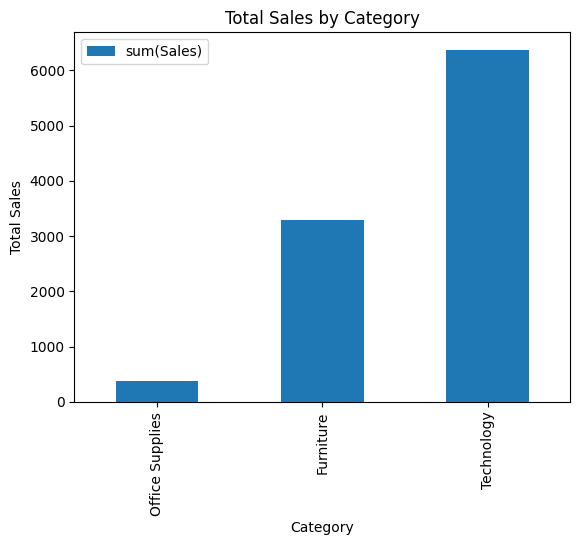

In [ ]:
import matplotlib.pyplot as plt

pandas_df.plot(kind='bar', x='Category', y='sum(Sales)')
plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.show()

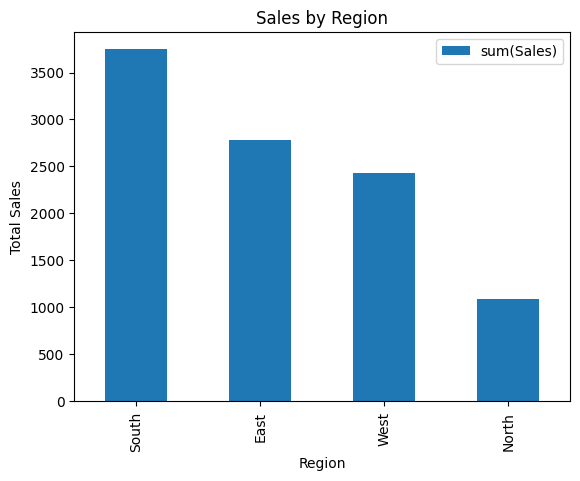

In [ ]:
region_sales = df.groupBy("Region").sum("Sales")
region_df = region_sales.toPandas()

region_df.plot(kind='bar', x='Region', y='sum(Sales)')
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.show()

Insights from the Analysis

The Technology category generated the highest sales compared to Furniture and Office Supplies.

The South and West regions contributed a significant portion of the total revenue.

Products like Laptop and Projector are among the top-selling items in the dataset.

Office Supplies products have higher quantities sold but lower sales value compared to Technology products.

Conclusion

In this project, PySpark was used to analyze a sales dataset and derive meaningful insights. The dataset was loaded from a CSV file, and various operations such as grouping, aggregation, and sorting were performed to analyze sales trends.

The analysis revealed key business insights such as top-performing product categories, regional sales distribution, and high-selling products. Additionally, data visualization using Matplotlib helped present the findings in a clear and understandable way.

This project demonstrates how big data tools like PySpark can efficiently process datasets and help organizations make data-driven business decisions.